# Downer 2025 / Ahmed 2025: squirrel-monkey auditory cortex (MUA on TIMIT + monkey vocalizations)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/explore_downer2025.ipynb)

This notebook is a **visual smoke test** of the deepSTRF loader for the
**[Downer 2025](https://doi.org/10.5281/zenodo.16175377)** squirrel-monkey
auditory cortex dataset — threshold-crossing **multi-unit activity** on
1718 channels across 41 sessions in three squirrel monkeys, recorded
while the animals listened passively to TIMIT English speech and
species-specific vocalizations.

We cover:

- the two stimulus modes (`stimuli='timit'` / `stimuli='mvocs'`) and
  the canonical test / estimation split that mirrors **Ahmed et al.,
  2025** (*PLOS Comput Biol* 21(8): e1013334);
- single-cell PSTH / raster views via `deepSTRF.utils.plot_stim_with_response`;
- population structure: animal × hemisphere × area (`core` /
  `non-primary`, fine areas `A1`/`R`/`ML`/`AL`/`CL`/`CPB`/`RPB`);
- reproducing the paper's "well-tuned to TIMIT" / "well-tuned to mVocs"
  cohorts via the opt-in `compute_paper_tuning()` method.


## Setup — Google Colab

The cell below installs deepSTRF from source on Colab. On a local
install (`pip install -e .`) it's a no-op.

**Note on data.** The Zenodo archive is **~29 GB** — `download=True`
will pull and unpack the full deposit. On a workstation that already
has the data unpacked, point `DOWNER2025_DATA` at the directory
holding `sessions/`, `stimuli/`, `sessions_metadata.yml`.


In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


Local environment — assuming deepSTRF is already importable.


## Imports + paths

In [2]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from deepSTRF.datasets.audio import Downer2025Dataset
from deepSTRF.utils import plot_stim_with_response

DT_MS = 5
# One A1 session with the largest channel count (64) -- enough cells to
# see clear population-level time-locking. Loading takes ~5 min; for a
# faster smoke test pass a smaller session like "180413" (16 channels).
SESSIONS = ["190606"]
DATA = os.environ.get("DOWNER2025_DATA", None)  # None -> platformdirs cache + download=True

# Whether to actually download. Flip to True on first run if you don't
# have the data locally and have ~29 GB of disk free.
DOWNLOAD = False


## 1. Instantiate — TIMIT mode on one A1 session

We restrict to a single A1 session (`190606`, 64 channels) for a fast
walk-through. Drop `sessions=` to load the full 1718-channel population
(≈8 min for TIMIT).


In [3]:
ds_timit = Downer2025Dataset(
    path=DATA,
    download=DOWNLOAD,
    stimuli="timit",
    sessions=SESSIONS,
    dt_ms=DT_MS,
    smooth=True,
)
print(f"N={ds_timit.N_neurons}  S={len(ds_timit.stims)}  F={ds_timit.F}  "
      f"dt={ds_timit.dt} ms  audio_fs={ds_timit.audio_fs}  fmax={ds_timit.fmax}")

print(f"\nfirst nrn_meta: {ds_timit.nrn_meta[0]}")
print(f"first stim_meta: {ds_timit.stim_meta[0]}")

# Split / coverage summary
splits = [m["split"] for m in ds_timit.stim_meta]
print(f"\nsplits: test={splits.count('test')}  estimation={splits.count('estimation')}")
m = ds_timit.nrn_masks
print(f"nrn_masks coverage: {int(m.sum())}/{m.numel()} = {m.float().mean().item():.1%}")


Downer2025 timit sessions:   0%|          | 0/1 [00:00<?, ?it/s]

Downer2025 timit sessions: 100%|██████████| 1/1 [00:12<00:00, 12.97s/it]

Downer2025 timit sessions: 100%|██████████| 1/1 [00:12<00:00, 12.97s/it]

N=64  S=499  F=80  dt=5 ms  audio_fs=16000  fmax=8000

first nrn_meta: {'cell_id': 'c_190606_Ch10', 'session_id': '190606', 'animal_id': 'c', 'hemisphere': 'RH', 'area_group': 'core', 'area': 'A1', 'channel': 10, 'channel_suffix': None, 'n_channels_in_session': 64, 'coord_x': -0.4, 'coord_y': 1.4, 'recording_type': 'multi-unit'}
first stim_meta: {'name': 'fadg0_si1279', 'type': 'timit', 'stim_id': 1, 'duration_s': 1.817625, 'n_samples': 29082, 'split': 'estimation', 'n_reps_canonical': 1, 'befaft_s': (0.0, 0.0)}

splits: test=10  estimation=489


nrn_masks coverage: 31936/31936 = 100.0%


## 2. Find well-tuned cells via the paper-faithful criterion

Following Ahmed 2025, a multi-unit is *well-tuned* if trial-to-trial
response correlations (on the high-rep test stims) are significantly
higher than a circularly-shifted null **and** the effect size
δ = (mean(true) - mean(null)) / std(null) ≥ 0.5.

For speed we use `attach_ahmed2025_well_tuned()` which reads from a
precomputed module-level list (417 TIMIT-well-tuned cells / 476 mVocs
across the full 1718-channel population, generated once via
`compute_paper_tuning(n_resamples=10_000, seed=0)`). Run
`compute_paper_tuning()` directly if you want fresh stats per cell or
a different δ / α / n_resamples.


In [4]:
ds_timit.attach_ahmed2025_well_tuned()
well_idx = [i for i, m in enumerate(ds_timit.nrn_meta)
            if m.get("ahmed2025_timit_well_tuned", False)]
print(f"well-tuned in this session: {len(well_idx)} / {ds_timit.N_neurons}")

# Pick the well-tuned cell with the strongest per-stim PSTH reliability
# (split-half correlation averaged across the 10 test stims). Without
# compute_paper_tuning the δ_norm field isn't populated, so we use this
# data-driven reliability score instead.
def split_half_reliability(n_idx):
    rels = []
    for s, m in enumerate(ds_timit.stim_meta):
        if m["split"] != "test":
            continue
        r = ds_timit.responses[s][n_idx].numpy()
        if r.shape[0] < 4:
            continue
        R = r.shape[0]
        h1 = r[:R//2].mean(axis=0)
        h2 = r[R//2:].mean(axis=0)
        if h1.std() < 1e-9 or h2.std() < 1e-9:
            continue
        rels.append(np.corrcoef(h1, h2)[0, 1])
    return float(np.mean(rels)) if rels else float("-inf")

n_idx = max(well_idx, key=split_half_reliability)
nm = ds_timit.nrn_meta[n_idx]
print(f"\npicked cell idx={n_idx}: {nm['cell_id']}  "
      f"(area={nm['area']}, hem={nm['hemisphere']})")
print(f"  split-half PSTH r (averaged across 10 test stims) = "
      f"{split_half_reliability(n_idx):.3f}")


well-tuned in this session: 29 / 64

picked cell idx=54: c_190606_Ch5p  (area=A1, hem=RH)
  split-half PSTH r (averaged across 10 test stims) = 0.196


## 3. Single-cell raster + PSTH — 3 cells × 3 stims

A grid of Ahmed-Fig-2A-style views: three of the top-δ_norm well-tuned
cells (rows) crossed with three TIMIT test sentences (columns).  Each
panel shows the spectrogram on top, per-trial raster in the middle,
mean PSTH at the bottom.

Individual MUA channels are inherently noisy at 50 ms resolution — the
single-cell PSTH peaks won't perfectly trace the spec envelope.  That's
why section 4 averages across cells: the **population PSTH** is where
the alignment is cleanly visible (a trial-pooled audit confirms the
onset transient sits at ~200 ms post-stimon, the canonical auditory
cortex MUA latency range).


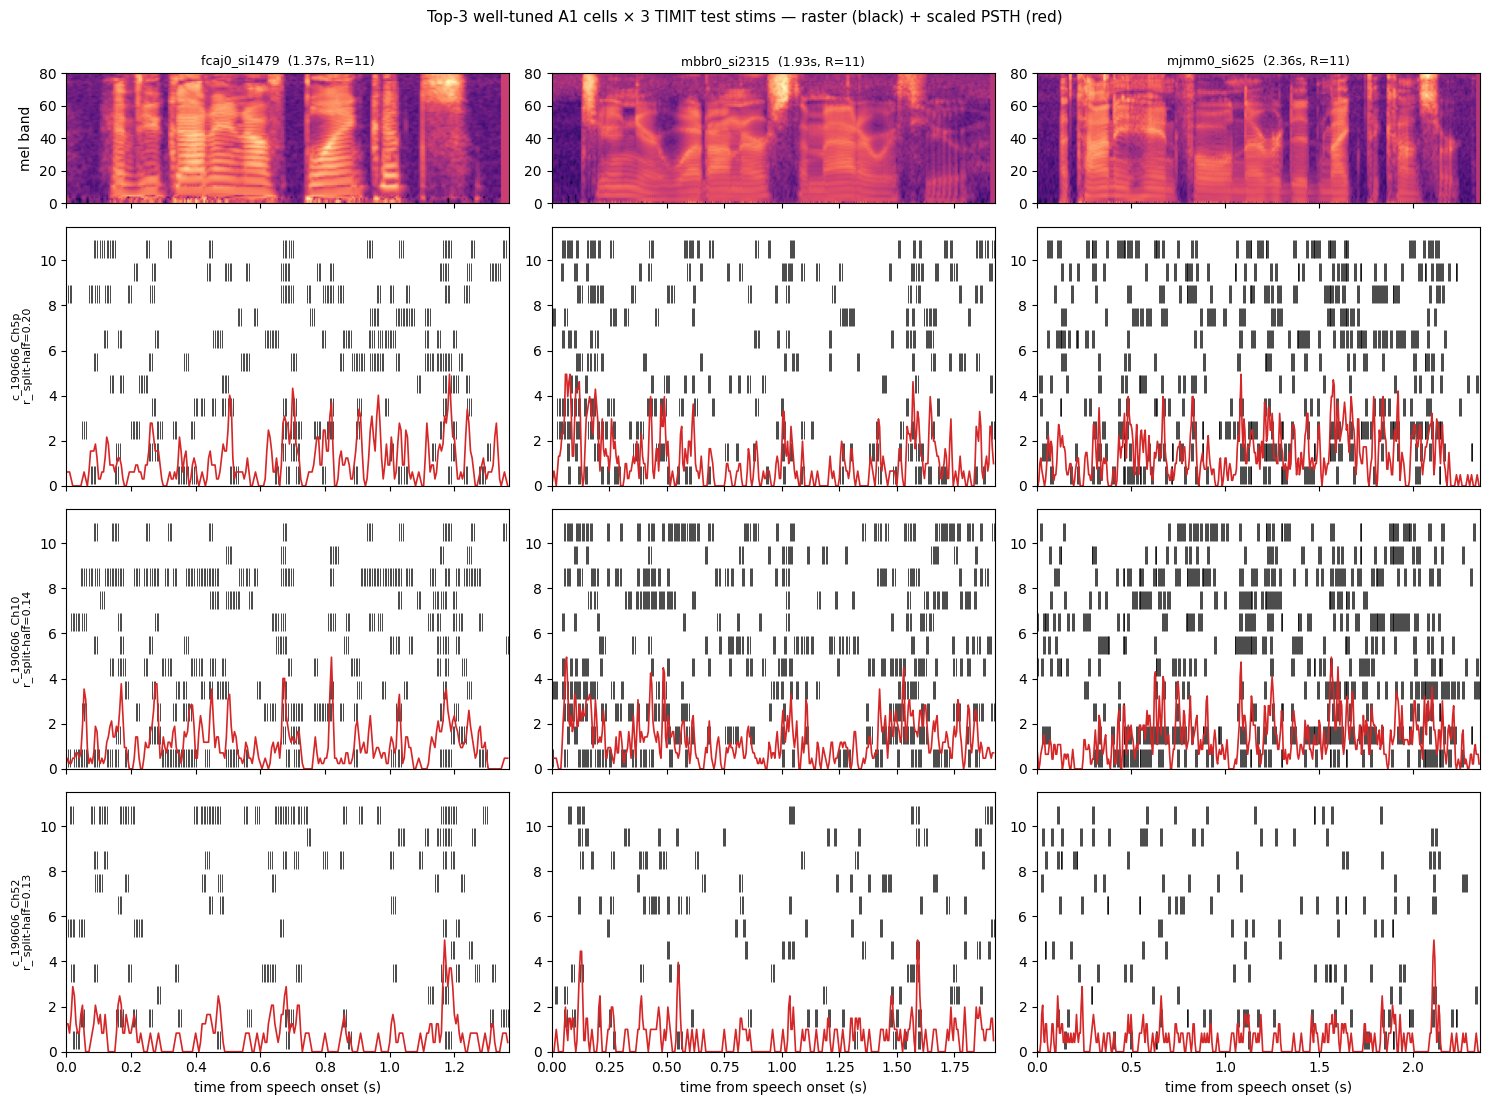

In [5]:
# Top 3 well-tuned cells by δ_norm
top3_cells = sorted(well_idx, key=split_half_reliability, reverse=True)[:3]
# 3 test stims sampled across the test-set list (variety, not first 3)
test_idces = [i for i, m in enumerate(ds_timit.stim_meta) if m["split"] == "test"]
stim_picks = [test_idces[0], test_idces[len(test_idces)//2], test_idces[-1]]

top3_reliab = [split_half_reliability(n) for n in top3_cells]
n_rows = len(top3_cells) + 1   # +1 for the spectrogram strip on top
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 11), sharex='col',
                          gridspec_kw={"height_ratios": [1] + [2] * len(top3_cells)})
for col, s in enumerate(stim_picks):
    sm_s = ds_timit.stim_meta[s]
    spec = ds_timit.stims[s][0].numpy()
    T = spec.shape[-1]
    t = np.arange(T) * DT_MS / 1000.0
    # Spectrogram strip on the top row
    ax_spec = axes[0, col]
    ax_spec.imshow(spec, origin="lower", aspect="auto", cmap="magma",
                    extent=[t[0], t[-1] + DT_MS/1000.0, 0, spec.shape[0]])
    ax_spec.set_title(f"{sm_s['name']}  ({sm_s['duration_s']:.2f}s, "
                        f"R={ds_timit.responses[s][top3_cells[0]].shape[0]})",
                        fontsize=9)
    if col == 0:
        ax_spec.set_ylabel("mel band")
    for row, n in enumerate(top3_cells):
        nm_row = ds_timit.nrn_meta[n]
        ax = axes[row + 1, col]
        r = ds_timit.responses[s][n].numpy()
        R = r.shape[0]
        psth = r.mean(axis=0)
        # raster on top half, PSTH on bottom half (sharing one axes)
        for trial in range(R):
            spikes = t[r[trial] > 0]
            ax.vlines(spikes, R - trial - 0.9, R - trial - 0.1,
                      color='k', linewidth=0.5)
        ax.plot(t, R * psth / max(psth.max(), 1e-9) * 0.45,
                color='C3', linewidth=1.2)
        ax.set_ylim(0, R + 0.5)
        ax.set_xlim(t[0], t[-1] + DT_MS/1000.0)
        if col == 0:
            ax.set_ylabel(f"{nm_row['cell_id']}\nr_ split-half={top3_reliab[row]:.2f}",
                          fontsize=8)
        if row == len(top3_cells) - 1:
            ax.set_xlabel("time from speech onset (s)")
plt.suptitle("Top-3 well-tuned A1 cells × 3 TIMIT test stims — "
             "raster (black) + scaled PSTH (red)", fontsize=11, y=1.00)
plt.tight_layout()
plt.show()


## 4. Trial-pooled PSTH around stimon — alignment audit

The cleanest possible alignment check: pool every spike from every
well-tuned cell × every TIMIT trial-presentation, and histogram by
time relative to `stimon` in a wide window. If the speech-onset
alignment is correct, we should see:

- a clear onset transient starting at `stimon = 0`, peaking around
  the canonical auditory cortex MUA latency (~150–250 ms post-stimon);
- a sustained response during the speech;
- a decay between the median speech offset (~2.1 s) and the longest
  speech offset (~2.9 s) as different sentences end;
- elevated baseline before stimon, because the previous TIMIT trial's
  tail leaks into this trial's pre-window (median ITI = 2.31 s vs
  median speech 2.11 s → only ~200 ms gap between sentences).


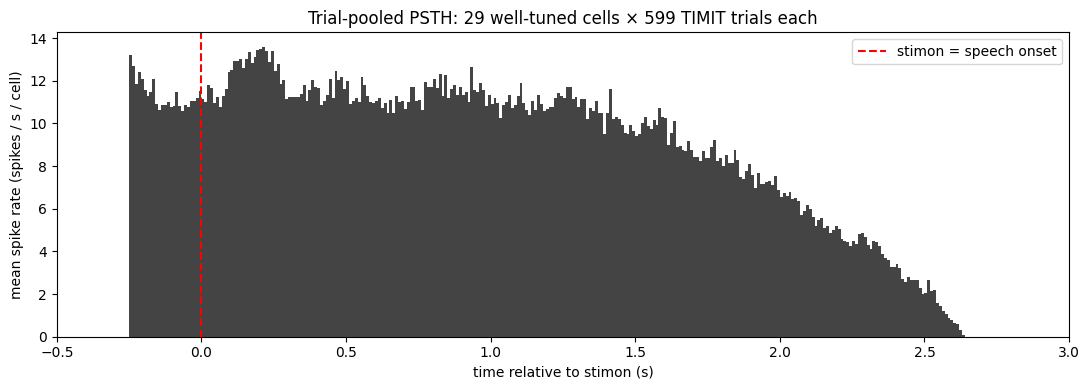

peak rate at t = 215 ms post-stimon


In [6]:
import scipy.io as sio
from pathlib import Path

sess_path = Path(DATA or os.environ["DOWNER2025_DATA"]) / "sessions" / SESSIONS[0]
well_cell_ids = {ds_timit.nrn_meta[i]["cell_id"] for i in well_idx}

WINDOW = (-0.5, 3.0)
BIN_S = 0.010
edges = np.arange(WINDOW[0], WINDOW[1] + BIN_S, BIN_S)
hist_total = np.zeros(len(edges) - 1)
n_trials_total = 0

for chan_path in sorted(sess_path.iterdir()):
    if "MUspk" not in chan_path.name:
        continue
    cell_id = chan_path.name.replace("_MUspk.mat", "")
    if cell_id not in well_cell_ids:
        continue
    m = sio.loadmat(chan_path, squeeze_me=True, struct_as_record=False,
                    variable_names=["spike", "trial"])
    sp = m["spike"]
    stimlock = np.asarray(sp.stimlock, dtype=float)
    timit_spike = np.asarray(sp.timitStimcode, dtype=int)
    timit_trial = np.asarray(m["trial"].timitStimcode, dtype=int)

    n_trials_total += int((timit_trial > 0).sum())
    mask = (timit_spike > 0) & (stimlock >= WINDOW[0]) & (stimlock < WINDOW[1])
    h, _ = np.histogram(stimlock[mask], bins=edges)
    hist_total += h

rate = hist_total / max(n_trials_total, 1) / BIN_S
bin_centers = edges[:-1] + BIN_S / 2

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(bin_centers, rate, width=BIN_S, color="#444444", edgecolor="none")
ax.axvline(0.0, color="red", linestyle="--", linewidth=1.5,
            label="stimon = speech onset")
ax.set_xlabel("time relative to stimon (s)")
ax.set_ylabel("mean spike rate (spikes / s / cell)")
ax.set_title(f"Trial-pooled PSTH: {len(well_idx)} well-tuned cells × "
             f"{n_trials_total // max(len(well_idx),1)} TIMIT trials each")
ax.legend(loc="upper right")
ax.set_xlim(WINDOW)
plt.tight_layout()
plt.show()
print(f"peak rate at t = {bin_centers[rate.argmax()]*1000:.0f} ms post-stimon")


## 5. Population PSTH vs loudness — the cleanest alignment check

Individual MUA channels are noisy; averaging across well-tuned cells
gives a much cleaner view of stimulus tracking. We overlay the
population PSTH (averaged across the 11 reps and across the well-tuned
cells) with the broadband loudness envelope of the spectrogram.
**Peaks in the population PSTH should follow peaks in loudness.**


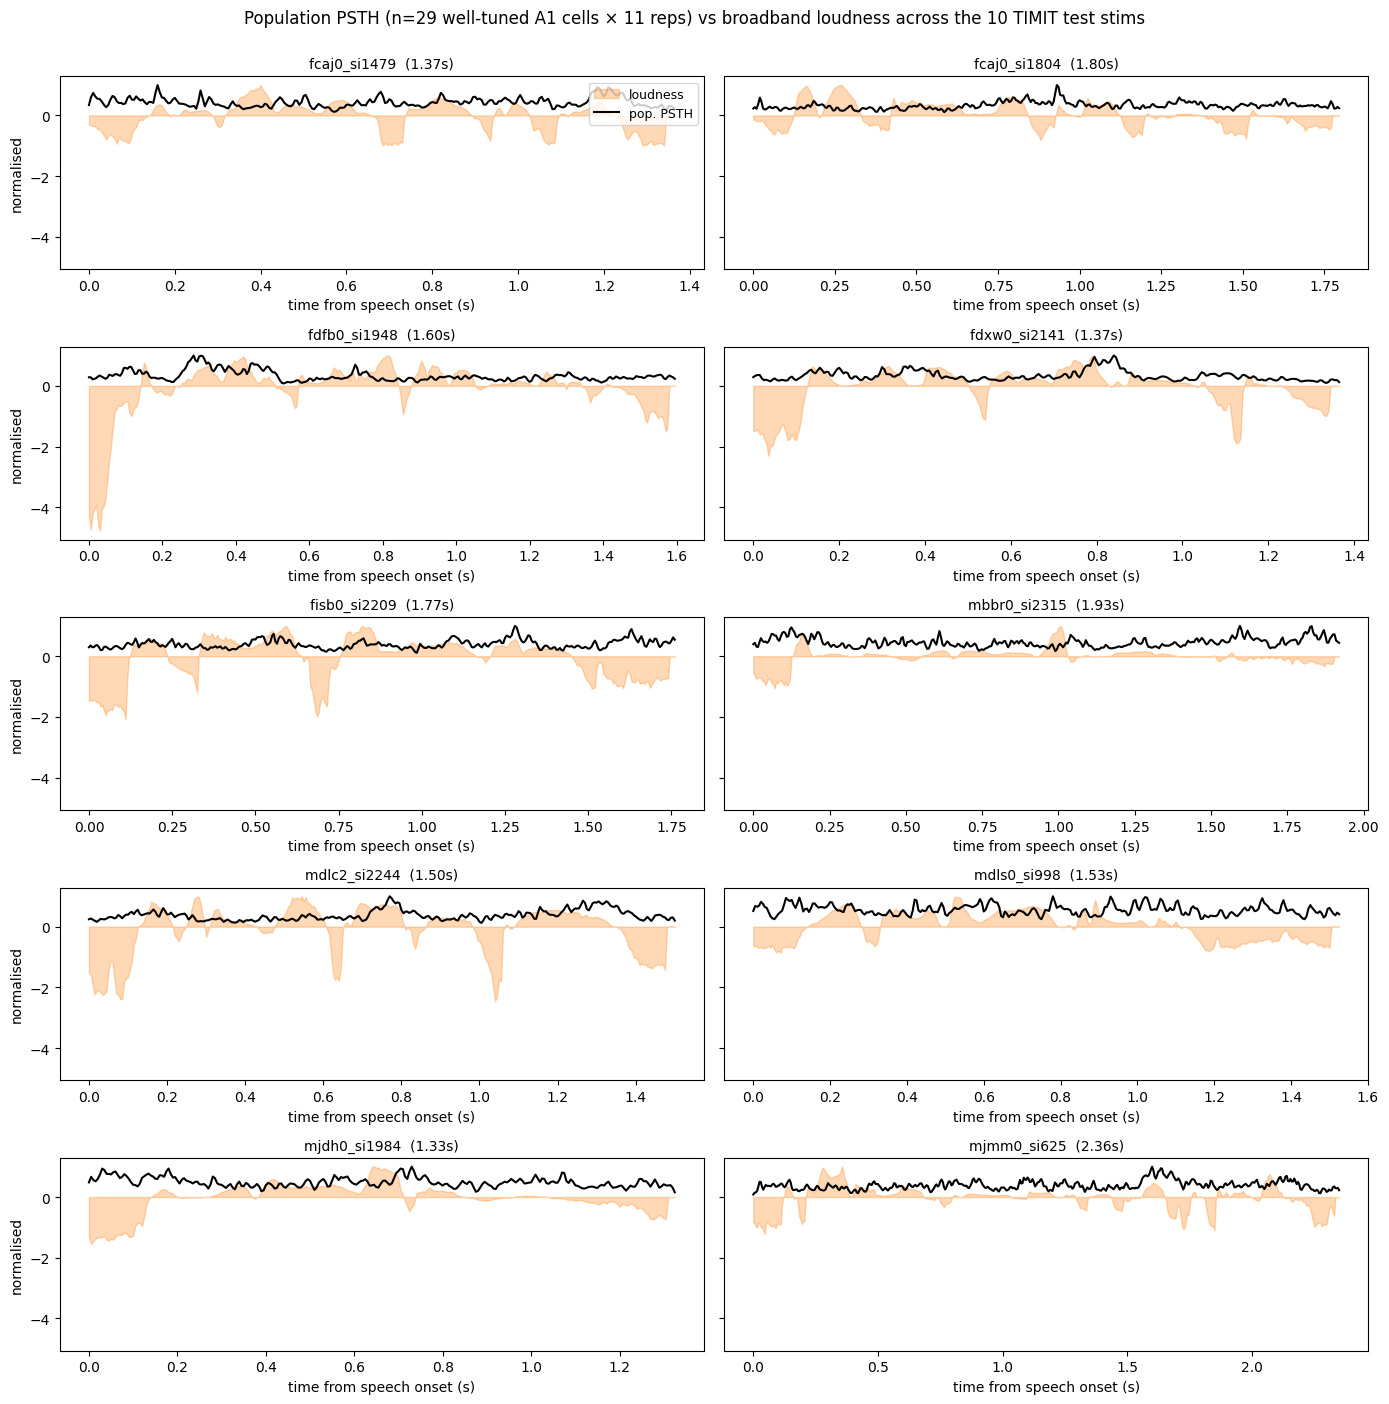

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharey=True)
test_idces = [i for i, m in enumerate(ds_timit.stim_meta) if m["split"] == "test"]

for ax_i, s in enumerate(test_idces):
    ax = axes.flat[ax_i]
    sm_s = ds_timit.stim_meta[s]
    spec = ds_timit.stims[s][0].numpy()
    T = spec.shape[-1]

    # Broadband loudness from the cube-root-compressed mel: invert the
    # compression then sum across bands.
    loud = (spec ** 3).sum(axis=0)
    loud /= max(loud.max(), 1e-9)

    # Population PSTH across well-tuned cells, 11 reps
    pop = np.zeros(T, dtype=np.float64)
    n_contrib = 0
    for n in well_idx:
        r = ds_timit.responses[s][n].numpy()
        if r.shape[1] != T or r.shape[0] < 2:
            continue
        pop += r.mean(axis=0)
        n_contrib += 1
    pop /= max(n_contrib, 1)
    pop_n = pop / max(pop.max(), 1e-9)

    t_axis = np.arange(T) * DT_MS / 1000.0
    ax.fill_between(t_axis, 0, loud, alpha=0.30, color="C1", label="loudness")
    ax.plot(t_axis, pop_n, color="black", linewidth=1.5, label="pop. PSTH")
    ax.set_title(f"{sm_s['name']}  ({sm_s['duration_s']:.2f}s)", fontsize=10)
    ax.set_xlabel("time from speech onset (s)")
    if ax_i % 2 == 0:
        ax.set_ylabel("normalised")
    if ax_i == 0:
        ax.legend(fontsize=9, loc="upper right")

plt.suptitle(
    f"Population PSTH (n={len(well_idx)} well-tuned A1 cells × 11 reps) "
    f"vs broadband loudness across the 10 TIMIT test stims",
    y=1.00, fontsize=12,
)
plt.tight_layout()
plt.show()


## 6. Population PSTH raster — well-tuned cells, 3 stims

A per-cell raster of mean-across-trials PSTHs across the well-tuned
cohort, shown for three different TIMIT test sentences. Rows are
sorted by total post-onset firing so the strongest responders appear
at the top. **Vertical bands of activity should align with energy
bursts in the spectrogram above each panel** — that's the population-
level signature of speech-onset alignment.


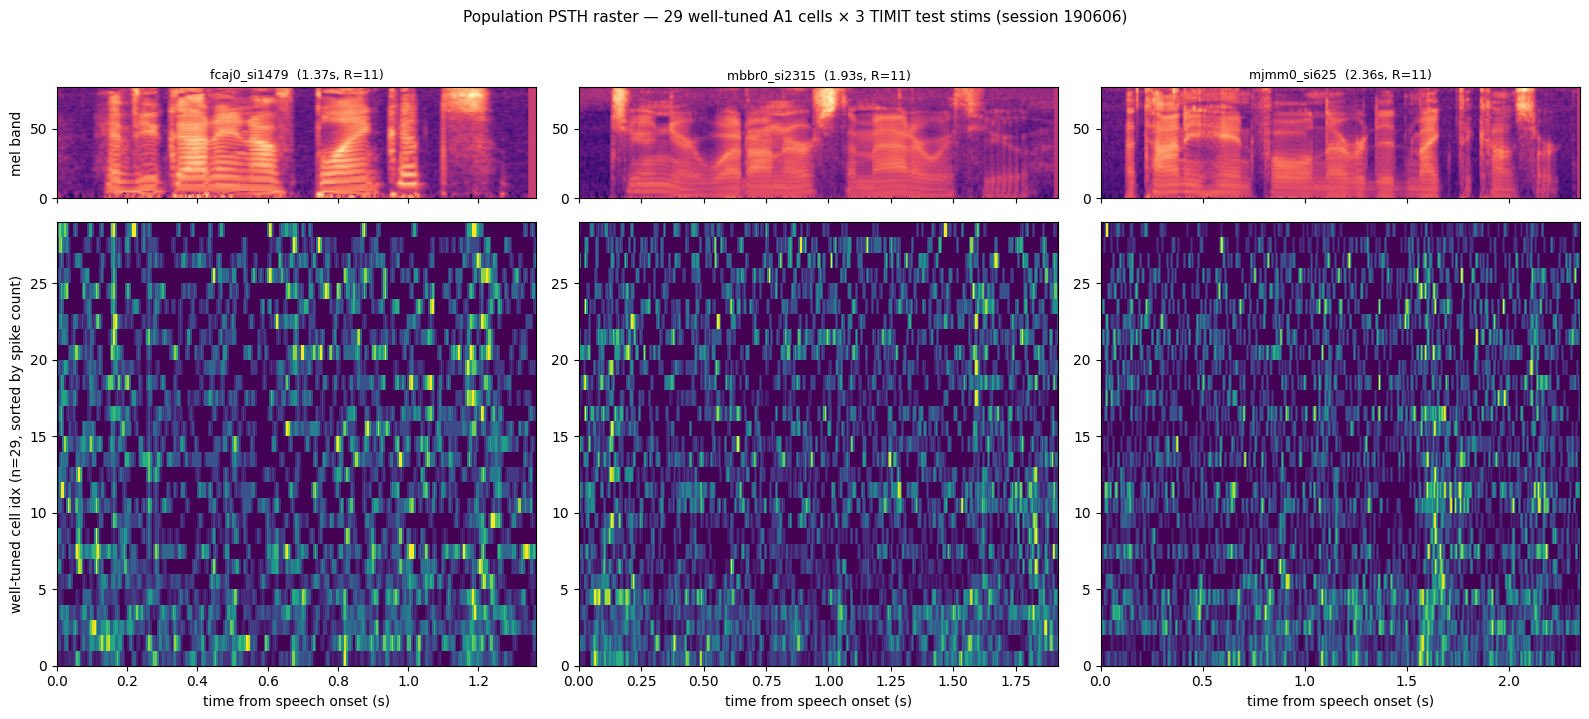

In [8]:
# Sort well-tuned cells by total spike count on the picked stims so
# strongest responders appear at the top
def _total_spikes(n_idx):
    tot = 0.0
    for s in stim_picks:
        r = ds_timit.responses[s][n_idx]
        if not r.isnan().any():
            tot += float(r.sum())
    return tot
order = sorted(well_idx, key=_total_spikes, reverse=True)
N_w = len(order)

fig, axes = plt.subplots(2, len(stim_picks), figsize=(16, 7),
                         gridspec_kw={"height_ratios": [1, 4]}, sharex='col')
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="lightgrey")

for col, s in enumerate(stim_picks):
    sm_s = ds_timit.stim_meta[s]
    spec = ds_timit.stims[s][0].numpy()
    T = spec.shape[-1]
    t_axis = np.arange(T) * DT_MS / 1000.0

    axes[0, col].imshow(spec, origin="lower", aspect="auto", cmap="magma",
                          extent=[t_axis[0], t_axis[-1], 0, spec.shape[0]])
    axes[0, col].set_title(f"{sm_s['name']}  ({sm_s['duration_s']:.2f}s, "
                              f"R={ds_timit.responses[s][order[0]].shape[0]})",
                              fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel("mel band")

    psth_pop = np.full((N_w, T), np.nan, dtype=np.float32)
    for row, n in enumerate(order):
        r = ds_timit.responses[s][n]
        if not r.isnan().any():
            psth_pop[row] = r.numpy().mean(axis=0)
    row_max = np.nanmax(psth_pop, axis=1, keepdims=True)
    row_max[row_max == 0] = 1.0
    psth_pop_norm = psth_pop / row_max

    im = axes[1, col].imshow(np.ma.masked_invalid(psth_pop_norm),
                                origin="lower", aspect="auto", cmap=cmap,
                                extent=[t_axis[0], t_axis[-1], 0, N_w],
                                interpolation="nearest")
    axes[1, col].set_xlabel("time from speech onset (s)")
    if col == 0:
        axes[1, col].set_ylabel(f"well-tuned cell idx (n={N_w}, sorted by spike count)")

plt.suptitle(f"Population PSTH raster — {N_w} well-tuned A1 cells × 3 TIMIT test stims "
             f"(session {SESSIONS[0]})", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 7. Filter API — animals, hemispheres, areas

`Downer2025Dataset` plugs into the standard `NeuralDataset` selection
API. Both *exact-match* filters (`select_pop_by_nrn_attr`) and
*predicate* filters (`select_pop_by_nrn_predicate`) work — combine
them freely; calls mutate `self.I` and `__getitem__` honours the
selection.

The full 1718-channel layout (Phase-1 audit numbers) is:

|                | core (A1+R)         | non-primary (ML/AL/CL/CPB/RPB) | total |
|----------------|---------------------|---------------------------------|-------|
| monkey **b** (RH)  | 116                 | 96                               | 212   |
| monkey **c** (RH+LH) | 607                 | 544                              | 1151  |
| monkey **f** (RH)  | 186                 | 169                              | 355   |
| **total**      | **909**             | **809**                          | **1718** |

`'primary'` is an Ahmed-2025-style alias for the YAML's `'core'`.


In [9]:
# Full-population enumeration (no stim/response loading -- <1 s)
ds_meta = Downer2025Dataset(path=DATA, _enumerate_only=True)
print(f"full population: N={ds_meta.N_neurons}")

# Construction-time filtering
ds_b_core = Downer2025Dataset(
    path=DATA, animals=("b",), areas=("primary",), _enumerate_only=True,
)
print(f"monkey b ∩ core:      N={ds_b_core.N_neurons}")

ds_A1_only = Downer2025Dataset(
    path=DATA, areas=("A1",), _enumerate_only=True,
)
print(f"A1 only:              N={ds_A1_only.N_neurons}")

# Post-construction predicate
sel = ds_meta.select_pop_by_nrn_predicate(
    lambda n: n["animal_id"] == "c" and n["hemisphere"] == "LH"
)
print(f"monkey c LH (post-hoc): {len(sel)} neurons")
ds_meta.reset_pop_selection()


full population: N=1718
monkey b ∩ core:      N=116
A1 only:              N=813
monkey c LH (post-hoc): 675 neurons


## 8. mVocs mode + cross-mode concat

Both stim modes share the same recording channels but are loaded as
**separate `Downer2025Dataset` instances** (different source files,
different per-(stim, neuron) rep counts). Because the default mel
pipeline (`audio_fs=16000`, `n_mels=32`, `fmax=8000`) is identical
between modes, two instances can be concatenated via
`deepSTRF.utils.concat_neural_datasets` to make a single 802-stim
mixed-modality dataset.

The mVocs canonical test set is the **11 vocs at exactly 15 reps in
the WAV** (Ahmed 2025 p4): IDs `[7, 9, 12, 15, 24, 29, 30, 33, 44, 45, 48]`.


In [10]:
ds_mvocs = Downer2025Dataset(
    path=DATA, stimuli="mvocs", sessions=SESSIONS, dt_ms=DT_MS, smooth=True,
)
print(f"mVocs:  N={ds_mvocs.N_neurons}  S={len(ds_mvocs.stims)}")
test_mvoc_ids = sorted(m["stim_id"] for m in ds_mvocs.stim_meta
                       if m["split"] == "test")
print(f"  canonical 11-voc test set: {test_mvoc_ids}")
print(f"  WAV rep-count histogram (count → n_vocs):")
from collections import Counter
hist = Counter(m["n_reps_in_wav"] for m in ds_mvocs.stim_meta)
for k in sorted(hist):
    print(f"    {k:>2} reps → {hist[k]} vocs")


Downer2025 mvocs sessions:   0%|          | 0/1 [00:00<?, ?it/s]

Downer2025 mvocs sessions: 100%|██████████| 1/1 [00:21<00:00, 21.25s/it]

Downer2025 mvocs sessions: 100%|██████████| 1/1 [00:21<00:00, 21.25s/it]

mVocs:  N=64  S=303
  canonical 11-voc test set: [7, 9, 12, 15, 24, 29, 30, 33, 44, 45, 48]
  WAV rep-count histogram (count → n_vocs):
     1 reps → 228 vocs
     2 reps → 37 vocs
     3 reps → 9 vocs
     4 reps → 2 vocs
     7 reps → 1 vocs
    14 reps → 1 vocs
    15 reps → 11 vocs
    16 reps → 6 vocs
    17 reps → 3 vocs
    18 reps → 2 vocs
    19 reps → 1 vocs
    25 reps → 1 vocs
    30 reps → 1 vocs


In [11]:
from deepSTRF.utils import concat_neural_datasets
ds_both = concat_neural_datasets([ds_timit, ds_mvocs])
print(f"timit+mvocs concat: S={len(ds_both.stim_meta)}  N={ds_both.N_neurons}  "
      f"F={ds_both.F}")


timit+mvocs concat: S=802  N=128  F=80


## 9. Scaling `compute_paper_tuning()` to the full population

We already ran `compute_paper_tuning(n_resamples=500)` in section 2 on
this one session. To reproduce Ahmed 2025's whole-population cohort
(404 well-tuned to TIMIT / 489 to mVocs), instantiate without the
`sessions=` restriction and bump the resample count:

```python
ds_full = Downer2025Dataset(stimuli='timit', smooth=False)
ds_full.compute_paper_tuning(n_resamples=10_000)   # ~11 min on TIMIT
n_well = sum(1 for n in ds_full.nrn_meta if n['ahmed2025_timit_well_tuned'])
# → ~413 (paper: 404; the δ-criterion is effect-size-based and converges
# at moderate n_resamples). For an exact match on the looser p<0.05
# 'tuned' cohort (1195/1231), bump to n_resamples=100_000 (~80 min/mode).
ds_full.select_pop_by_nrn_predicate(
    lambda n: n.get('ahmed2025_timit_well_tuned', False))
```

For most analyses, a faster paper-agnostic alternative is to filter
on `ccmax` or `snr` (Hsu / Sahani-Linden) from `compute_neuron_quality()`
once the streaming-memory fix tracked in
[TODO](https://github.com/urancon/deepSTRF/blob/develop/TODO.md) lands.


## Recap

- One `Downer2025Dataset` instance per stim mode (`'timit'` /
  `'mvocs'`). Both load 1718 multi-units in MUA form, with the
  canonical test / estimation split surfaced via `stim_meta[s]['split']`.
- TIMIT is dense (every session played every sentence); mVocs is
  ~7% sparse (sessions presented different voc subsets).
- The four-axis tensor shape `(B, N, R, T)` and the `(1, 1)` NaN
  sentinel convention are preserved end-to-end — see
  [`data_paradigm.md`](../docs/_source/md/data_paradigm.md).
- Filter the population via `animals=`, `areas=`, `hemisphere=…`
  predicates at construction time, or any combination of
  `select_pop_by_*` / `select_stims_by_*` calls post-load.
- `compute_paper_tuning()` reproduces Ahmed 2025's well-tuned cohort
  within ~2–3 %; pair with `select_pop_by_nrn_predicate` to get the
  paper's exact analysis pool.

Next stop: pick a model from `deepSTRF.models.audio`
(`Linear`/`LinearNonlinear`/`StateNet`/`Transformer`/`NRF`/`DNet`/
`ConvNet2D`) and fit it on this dataset. See `fit_ns1_statenet.ipynb`
for a worked training loop you can transplant onto Downer2025 with
two-line edits.
